# Feature Exploration — Temperature Forecasting

Before training the LSTM, it's worth understanding what signal is actually
sitting in the dataset `real_data/fetch_data.py` produced. This notebook
walks through exploring `real_data/berlin_data.csv` (or whichever station
you fetched): looking at correlations, variance, and other summary
statistics for each feature relative to the **target** you're trying to
forecast, `temperature_2m`.

Each section below has a short explanation and a task. The code cells are
left empty on purpose — write your own code there to complete the task
before moving to the next section.

## 1. Load the data

`fetch_data.py` saved the aligned truth + NWP-forecast dataset to
`real_data/<station>_data.csv`, indexed by timestamp.

**Task:** Load the CSV with pandas. Make sure the date column becomes a
proper `DatetimeIndex` (not just a string column) — you'll need that for
the time-based work later in this notebook.

In [198]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import os
import numpy as np
import matplotlib.pyplot as plt

#ucitavanje i sredjivanje podataka

df=pd.read_csv("/home/polaznik/Desktop/nevena/TemperatureForecasting/real_data/petnica_data.csv")
#print(df.head())

#df = df.iloc[600:]

#df = df.reset_index(drop=True)
total_missing_rows = df.isna().any(axis=1).sum()
print("hello nema ovoliko", total_missing_rows)

print(df.head())


df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtype)

hello nema ovoliko 25675
                        date  temperature_2m  relative_humidity_2m  \
0  2022-01-01 00:00:00+00:00           9.482                  79.0   
1  2022-01-01 01:00:00+00:00           9.682                  77.0   
2  2022-01-01 02:00:00+00:00          10.382                  74.0   
3  2022-01-01 03:00:00+00:00          10.132                  73.0   
4  2022-01-01 04:00:00+00:00          10.182                  72.0   

   dew_point_2m  rain  showers  snowfall  snow_depth  weather_code  \
0      6.021022   0.0      0.0       0.0         0.0           3.0   
1      5.844214   0.0      0.0       0.0         0.0           3.0   
2      5.946612   0.0      0.0       0.0         0.0           3.0   
3      5.508911   0.0      0.0       0.0         0.0           3.0   
4      5.358261   0.0      0.0       0.0         0.0           3.0   

   pressure_msl  ...  soil_temperature_10_to_40cm  soil_moisture_0_to_10cm  \
0        1021.4  ...                        7.432      

## 2. Get familiar with the data

Before any modeling, always check the basics — shape, column types,
missing values, and the date range actually covered. These often reveal
fetch bugs or gaps you'd otherwise miss.

**Task:**
- Print the shape of the DataFrame and its column dtypes.
- Count missing values per column.
- Print the first and last timestamp to confirm the covered date range.

In [199]:
df.info()
df.columns
df.shape
df.dtypes
df.head()
df.tail()
#

<class 'pandas.DataFrame'>
RangeIndex: 40488 entries, 0 to 40487
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   date                           40488 non-null  datetime64[us, UTC]
 1   temperature_2m                 40488 non-null  float64            
 2   relative_humidity_2m           40488 non-null  float64            
 3   dew_point_2m                   40488 non-null  float64            
 4   rain                           22801 non-null  float64            
 5   showers                        40488 non-null  float64            
 6   snowfall                       22801 non-null  float64            
 7   snow_depth                     40488 non-null  float64            
 8   weather_code                   22798 non-null  float64            
 9   pressure_msl                   40488 non-null  float64            
 10  surface_pressure               40

,date,temperature_2m,relative_humidity_2m,dew_point_2m,rain,showers,snowfall,snow_depth,weather_code,pressure_msl,...,soil_temperature_10_to_40cm,soil_moisture_0_to_10cm,soil_moisture_10_to_40cm,soil_moisture_40_to_100cm,soil_temperature_100_to_200cm,soil_temperature_40_to_100cm,temperature_2m_previous_day1,temperature_2m_previous_day3,temperature_2m_previous_day5,temperature_2m_previous_day7
40483,2026-08-14 19:00:00+00:00,21.632000,41.0,7.812610,0.0,0.0,0.0,0.0,0.0,1017.7,...,19.532,0.047,0.048,0.048,13.382,16.532,24.1165,23.838501,24.488499,24.788502
40484,2026-08-14 20:00:00+00:00,20.932001,44.0,8.220187,0.0,0.0,0.0,0.0,0.0,1018.2,...,19.532,0.047,0.048,0.048,13.382,16.532,22.0665,23.288502,23.838501,23.688500
40485,2026-08-14 21:00:00+00:00,20.232000,46.0,8.239429,0.0,0.0,0.0,0.0,0.0,1018.4,...,19.532,0.047,0.048,0.048,13.382,16.532,20.5165,22.938500,23.288502,22.588501
40486,2026-08-14 22:00:00+00:00,19.832000,48.0,8.502102,0.0,0.0,0.0,0.0,0.0,1018.5,...,19.532,0.047,0.048,0.048,13.382,16.532,19.7665,21.938500,22.738499,21.538502
40487,2026-08-14 23:00:00+00:00,19.532000,48.0,8.227393,0.0,0.0,0.0,0.0,0.0,1018.6,...,19.532,0.047,0.048,0.048,13.382,16.532,19.1165,21.138500,22.238499,20.738499


## 3. Visualize the target over time

Plotting the raw series is the fastest way to spot obvious patterns —
daily cycles, seasonal trend, missing chunks, or outliers — before diving
into summary numbers.

**Task:**
- Plot `temperature_2m` against the date index for the full dataset.
- Then plot just a single week of it, so the daily cycle is clearly
  visible.

/tmp/ipykernel_314722/2533512390.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


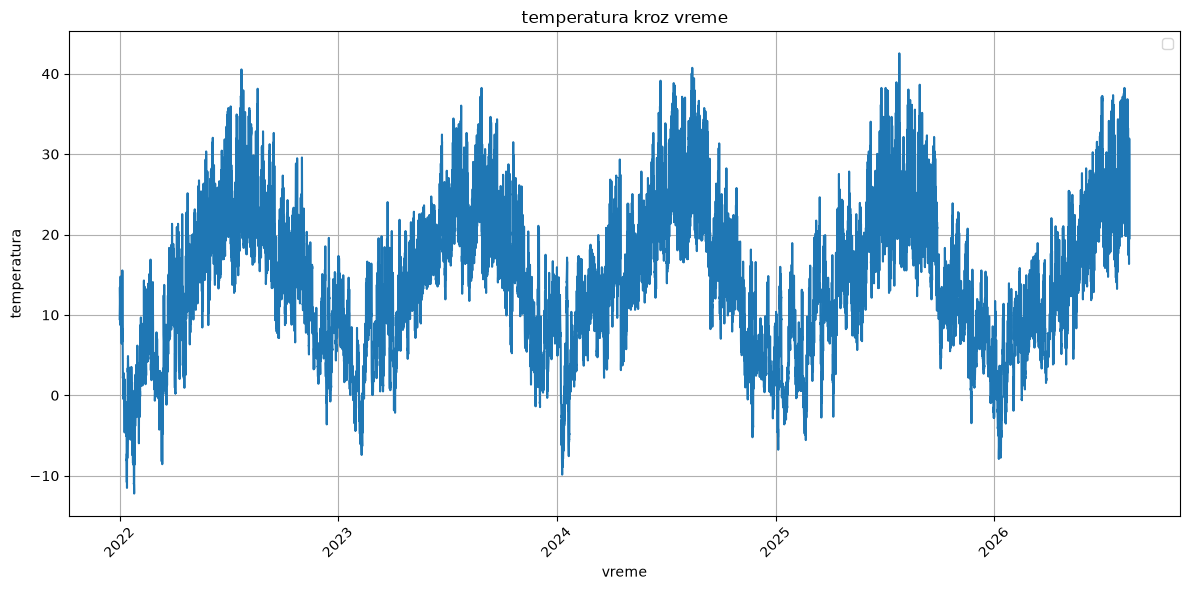

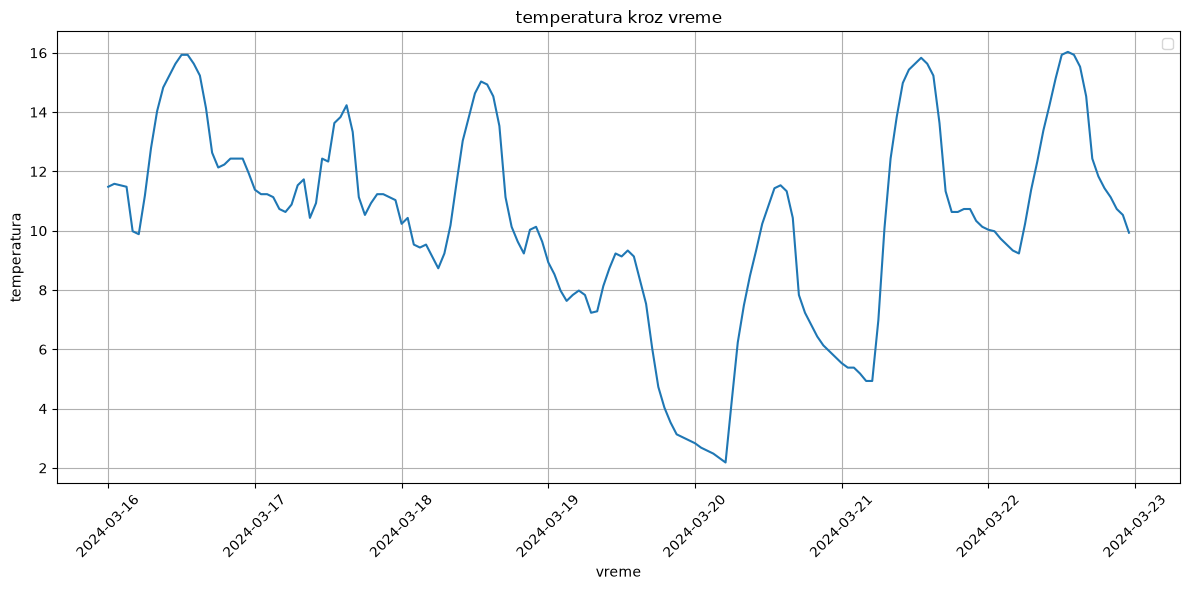

In [200]:


def plot(x, y):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)


    plt.xlabel("vreme")
    plt.ylabel("temperatura")
    plt.title("temperatura kroz vreme")
    plt.legend()
    plt.grid(True)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

temp = df['temperature_2m']
date= df['date']
plot(date, temp)


nedelja = df[
    (df["date"] >= "2024-03-16 00:00:00+00:00") &
    (df["date"] < "2024-03-23 00:00:00+00:00")
]

tempnedelja = temp[
    (df["date"] >= "2024-03-16 00:00:00+00:00") &
    (df["date"] < "2024-03-23 00:00:00+00:00")
]

plot(nedelja["date"],tempnedelja)

## 4. Distribution of each feature

A histogram shows you the spread, skew, and any suspicious outliers in a
feature — things a single mean/std number can hide.

**Task:**
- Plot a histogram for every numeric column (`DataFrame.hist()` does this
  for all columns at once).
- Note anything that looks off: an unexpected spike, a suspiciously flat
  distribution, or values that seem out of physical range.

In [201]:
df.hist(figsize=(30, 20), bins=30)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 5. Correlation coefficients with the target

The Pearson correlation coefficient measures the strength of the
*linear* relationship between two variables, from -1 (perfect negative)
to +1 (perfect positive), with 0 meaning no linear relationship. Keep in
mind: two variables can have a strong *non-linear* relationship and still
show a weak Pearson correlation, so this isn't the whole picture — just a
useful first pass.

**Task:**
- Compute the Pearson correlation of every feature with `temperature_2m`
  (`DataFrame.corr()`), and sort the results by absolute value.
- Which feature correlates most strongly with the target? Does that match
  your intuition?
- Plot the full correlation matrix as a heatmap so you can see how
  features relate to *each other*, not just to the target.

korelacije sa merenom temperaturom  temperature_2m                   1.000000
temperature_80m                  0.979947
surface_temperature              0.977261
temperature_2m_previous_day1     0.975557
temperature_2m_previous_day3     0.972577
temperature_2m_previous_day5     0.959030
temperature_2m_previous_day7     0.928050
soil_temperature_0_to_10cm       0.918142
soil_temperature_10_to_40cm      0.780677
dew_point_2m                     0.769683
soil_temperature_40_to_100cm     0.638422
visibility                       0.299305
soil_temperature_100_to_200cm    0.251740
wind_speed_10m                   0.112594
showers                          0.080568
wind_speed_80m                   0.030268
wind_gusts_10m                  -0.007855
rain                            -0.073216
cloud_cover_high                -0.101941
snowfall                        -0.172655
wind_direction_10m              -0.173142
wind_direction_80m              -0.173353
weather_code                    -0.18490

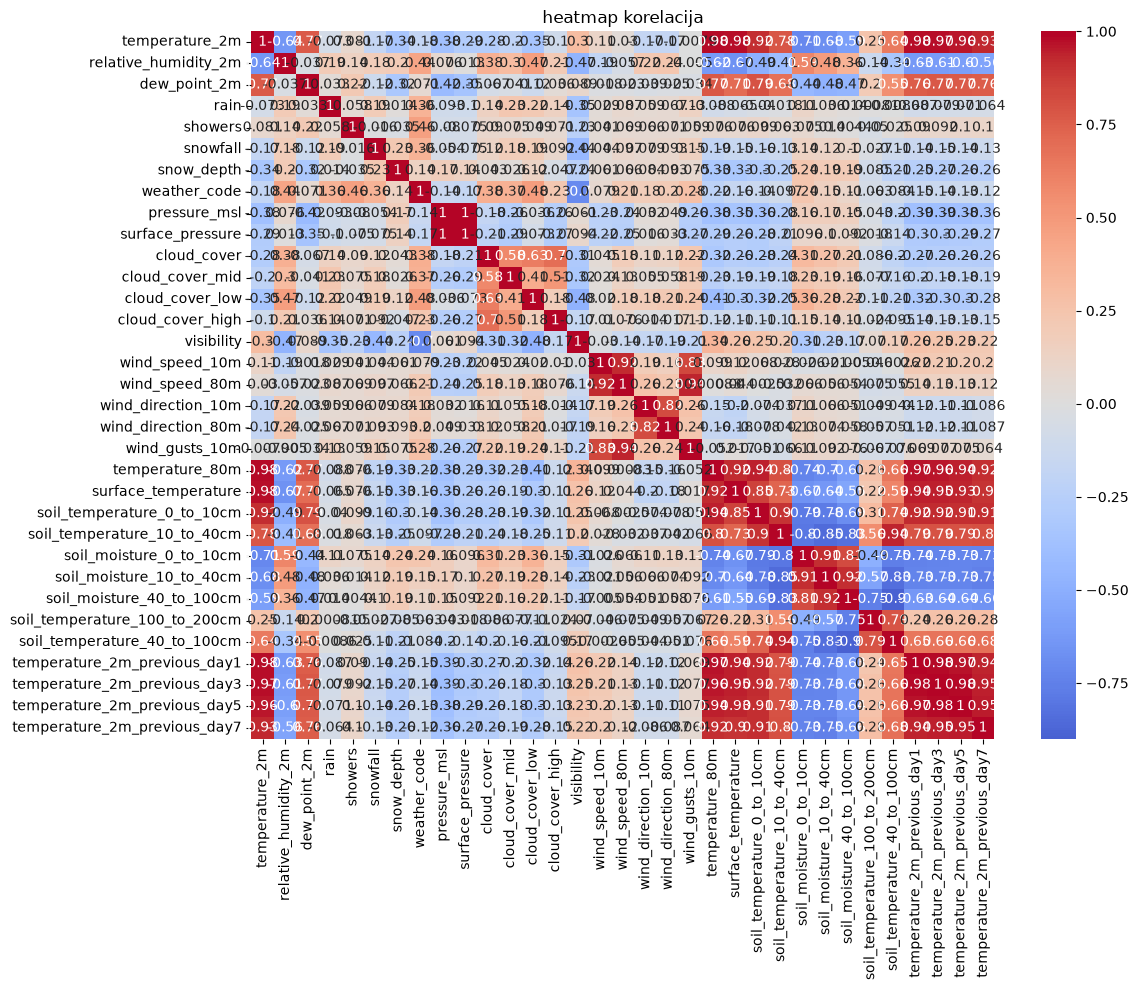

In [ ]:
korelacije = df.corr(numeric_only=True)["temperature_2m"]

korelacije = korelacije.sort_values(
    ascending=False
)

print("korelacije sa merenom temperaturom ", korelacije)

import seaborn as sns

korelacijesve=df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    korelacijesve,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("heatmap korelacija")
plt.tight_layout()
plt.show()


temp1d = korelacije["temperature_2m_previous_day1"]


## 6. Variance and spread of each feature

Variance measures how spread out a feature's values are around its mean.
A feature with (near) zero variance carries almost no information — it
barely changes, so it can't help a model distinguish one moment from
another, no matter how "correlated" it superficially looks.

Because these features live on very different scales (temperature in °C
vs. pressure in hPa), raw variance isn't directly comparable across
columns. The **coefficient of variation** (`std / mean`) is a scale-free
way to compare spread across variables with different units.

**Task:**
- Compute the variance and standard deviation of each numeric column.
- Compute the coefficient of variation for each column and compare it
  across variables.
- Are there any near-constant columns that might not be useful for the
  model?

In [ ]:
brojevi = df.select_dtypes(include="number")

#variance - kvadratna srednja vrednost odstupanja

variance= brojevi.var()
print("--------ovo su variance", variance)

#standardna devijacija - srednja vrednost odstupanja
stdevijacija=brojevi.std()
print("--------ovo je standardna devijaicja", stdevijacija)
#koeficient 
coefvariation=stdevijacija/brojevi.mean()
print("------------------\n",coefvariation)

--------ovo su variance temperature_2m                   8.005250e+01
relative_humidity_2m             3.975302e+02
dew_point_2m                     4.112232e+01
rain                             1.252001e-01
showers                          3.500021e-02
snowfall                         5.670722e-03
snow_depth                       1.138584e-03
weather_code                     4.580455e+02
pressure_msl                     6.036495e+01
surface_pressure                 5.355329e+01
cloud_cover                      1.981809e+03
cloud_cover_mid                  1.720514e+03
cloud_cover_low                  1.853911e+03
cloud_cover_high                 1.984485e+03
visibility                       3.363981e+07
wind_speed_10m                   2.747440e+01
wind_speed_80m                   7.314183e+01
wind_direction_10m               8.342551e+03
wind_direction_80m               8.799108e+03
wind_gusts_10m                   1.124345e+02
temperature_80m                  7.711489e+01
surface_te

In [ ]:
#da mozemo da poredimo
coefvariation=stdevijacija/brojevi.mean()
print(coefvariation)
uprocentima=coefvariation*100
print("u procentima", uprocentima.sort_values())



#surface pressure je near-constant

temperature_2m                   0.636601
relative_humidity_2m             0.295478
dew_point_2m                     0.893050
rain                             7.054140
showers                          5.002069
snowfall                         8.217330
snow_depth                       5.135062
weather_code                     1.999659
pressure_msl                     0.007639
surface_pressure                 0.007375
cloud_cover                      0.772803
cloud_cover_mid                  1.525743
cloud_cover_low                  1.347988
cloud_cover_high                 1.187115
visibility                       0.263965
wind_speed_10m                   0.552123
wind_speed_80m                   0.716873
wind_direction_10m               0.452791
wind_direction_80m               0.449369
wind_gusts_10m                   0.852166
temperature_80m                  0.611850
surface_temperature              0.702259
soil_temperature_0_to_10cm       0.523811
soil_temperature_10_to_40cm      0

## 7. Autocorrelation of the target

Since this is a time series, how strongly a value relates to its *own*
past values (autocorrelation) matters a lot — it directly informs how
large a lookback window the LSTM needs to see useful history. The
autocorrelation at lag *k* is the correlation between the series and a
copy of itself shifted by *k* steps (`Series.autocorr(lag=k)`).

**Task:**
- Compute the autocorrelation of `temperature_2m` at lags of 1, 6, 12,
  24, 48, and 168 hours (1 hour up to 1 week).
- Plot autocorrelation vs. lag. At what lag does it drop off? What does
  that suggest about how many past hours the LSTM's input window should
  cover?

*(Optional stretch: `statsmodels.graphics.tsaplots.plot_acf` gives a
nicer ACF plot with confidence intervals built in.)*

[np.float64(0.9914147238995055), np.float64(0.9725225911690702), np.float64(0.9476960697993178), np.float64(0.9193387114883648), np.float64(0.8893239552908637), np.float64(0.8593552000157799), np.float64(0.8310231043595769), np.float64(0.805768841435765), np.float64(0.7844012947019483), np.float64(0.7675409324332373), np.float64(0.7557463592698279), np.float64(0.7500465963057615), np.float64(0.7508498453752088), np.float64(0.75771717956797), np.float64(0.7695148834142511), np.float64(0.7855222635259101), np.float64(0.8050851627435944), np.float64(0.8273557607533352), np.float64(0.850999758307317), np.float64(0.874379812260959), np.float64(0.8957510585091316), np.float64(0.913304066377333), np.float64(0.9249333228370372), np.float64(0.9276543753950354), np.float64(0.9193433204047617), np.float64(0.9022275177711373), np.float64(0.8793568923468276), np.float64(0.8529056082205908), np.float64(0.8246930952290066), np.float64(0.7963988232616137), np.float64(0.7696574402638965), np.float64(0.

/tmp/ipykernel_314722/2461346463.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


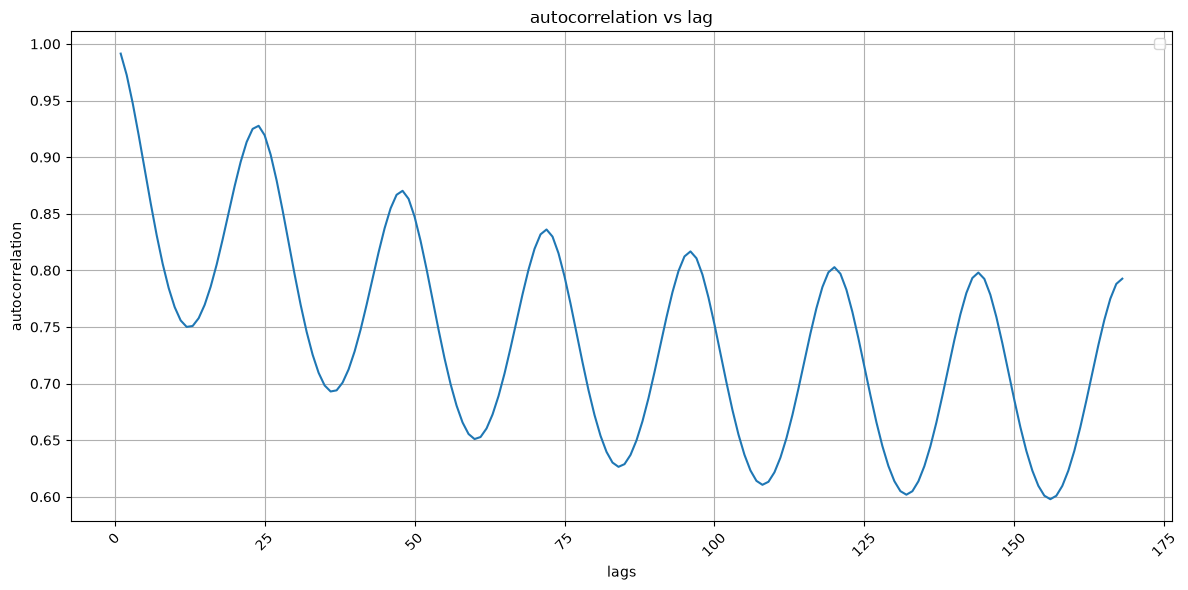

In [ ]:
temp=df["temperature_2m"]
lags=[1,6,12,24,48,168]

lags = [i+1 for i in range(168)]

autocorrelation=[]

for lag in lags:
    vrednost=temp.autocorr(lag=lag)
    autocorrelation.append(vrednost)

print(autocorrelation)

def plot1(x, y, x1, y1, naziv):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)


    plt.xlabel(x1)
    plt.ylabel(y1)
    plt.title(naziv)
    plt.legend()
    plt.grid(True)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot1(lags,autocorrelation, "lags", "autocorrelation", "autocorrelation vs lag")

#smanjuje se do otp 12h i onda opet raste do oko 24h, a zatim se sve vise smanjuje
#mislim da bi trebalo koristiti podatke do 48 sati unazad, ali nebi bio preveliki problem uzeti i podatke od nedeju dana jer je koeficient oko 80 sto je takodje veliko 

## 8. How good is the NWP baseline already?

The `temperature_2m_previous_day{N}` columns aren't just another
feature — they're the archived operational NWP forecast made N days
before each timestamp. Comparing them against the true `temperature_2m`
tells you how strong a "physics baseline" the LSTM will eventually be
measured against.

**Task:**
- For each `temperature_2m_previous_day{N}` column, compute its
  correlation with `temperature_2m`, and its RMSE against
  `temperature_2m`.
- How do correlation and RMSE change as the lead time N grows? Does that
  match your expectations about forecast skill decaying with lead time?

In [ ]:

df2 = df.iloc[600:]

df2 = df2.reset_index(drop=True)

t21=df2["temperature_2m_previous_day1"]
t23=df2["temperature_2m_previous_day3"]
t25=df2["temperature_2m_previous_day5"]
t27=df2["temperature_2m_previous_day7"]


#temp1d = korelacije()
temp3d = korelacije["temperature_2m_previous_day3"]
temp5d = korelacije["temperature_2m_previous_day5"]
temp7d = korelacije["temperature_2m_previous_day7"]

print(temp1d,temp3d,temp5d,temp7d)


def srednjakvadratna(predikcija):
   
    y_true = df2["temperature_2m"]
    y_pred = df2[predikcija]

    maska = y_true.notna() & y_pred.notna()

    y_true = y_true[maska]
    y_pred = y_pred[maska]
    mse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mse


srkgreska1d= srednjakvadratna("temperature_2m_previous_day1")
srkgreska3d= srednjakvadratna("temperature_2m_previous_day3")
srkgreska5d= srednjakvadratna("temperature_2m_previous_day5")
srkgreska7d= srednjakvadratna("temperature_2m_previous_day7")

print(srkgreska1d,srkgreska3d,srkgreska5d,srkgreska7d)

#sto je ranija predikcija, to je manja korelacija, a rmse veca

0.9755572591245273 0.972576929293327 0.9590303662750005 0.928049730746462
2.1263523347877196 2.140712128556873 2.604747643045135 3.435671325212598


## 9. Summary

Write a short summary of what you found. There's no single right
answer here — the point is to reason from what you actually saw above.

**Your answers:**

- Which features look most useful for forecasting temperature?

  Imamo samo jos jedan feature, sto je surface temperature, a korelacija njega i temperature je prilicno mala tako da mislim da nije preterano koristan za to.

- Are there any features you'd drop, or engineer differently (e.g.
  combine, transform)?

  Mislim da ne, takodje, verovatno bi bila dobra ideja preuzeti jos neki feature osim surface pressure.

- Based on the autocorrelation, how far back should the LSTM's input
  window look?

Mislim da bi trebalo koristiti podatke do 48 sati unazad, ali nebi bio preveliki problem uzeti i podatke od nedeju dana jer je koeficient oko 80 sto je takodje veliko.

- How big a gap does the LSTM need to close relative to the NWP
  baseline?

  *(your answer here)*

Standardization


33
0   -0.511072
1   -0.488718
2   -0.410481
3   -0.438423
4   -0.432835
Name: temperature_2m, dtype: float64
temperature_2m


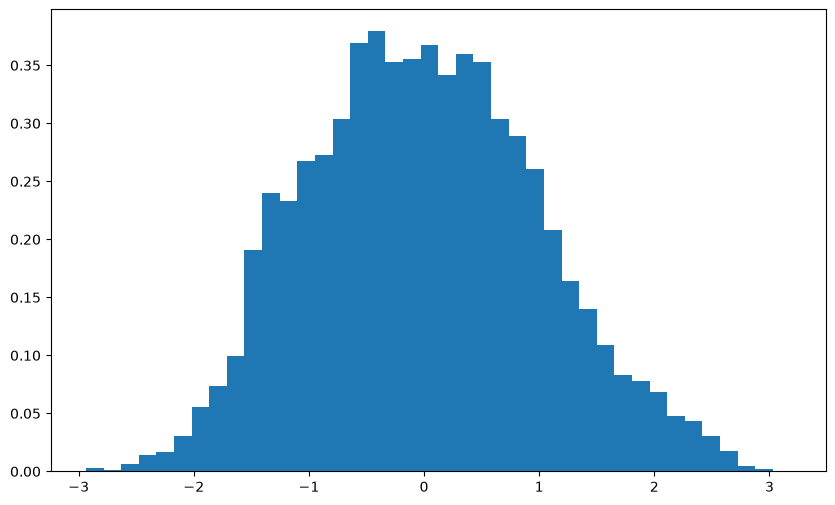

0    0.577909
1    0.477599
2    0.327134
3    0.276979
4    0.226824
Name: relative_humidity_2m, dtype: float64
relative_humidity_2m


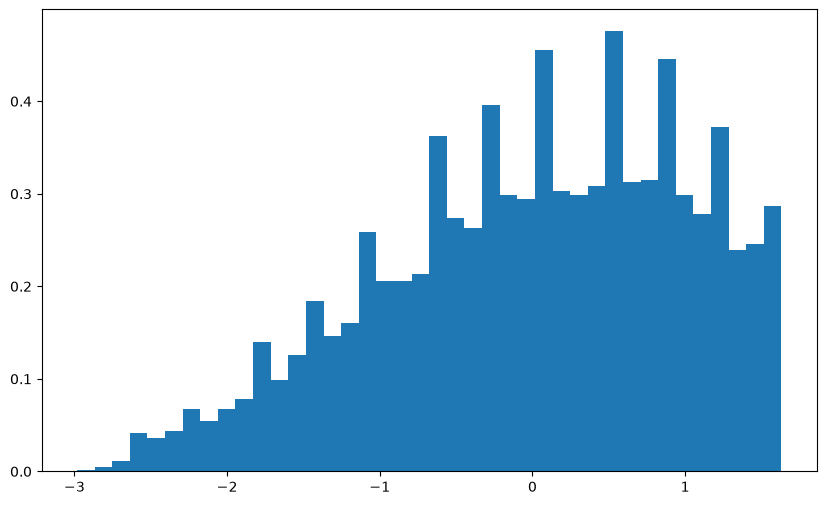

0   -0.180832
1   -0.208404
2   -0.192436
3   -0.260692
4   -0.284184
Name: dew_point_2m, dtype: float64
dew_point_2m


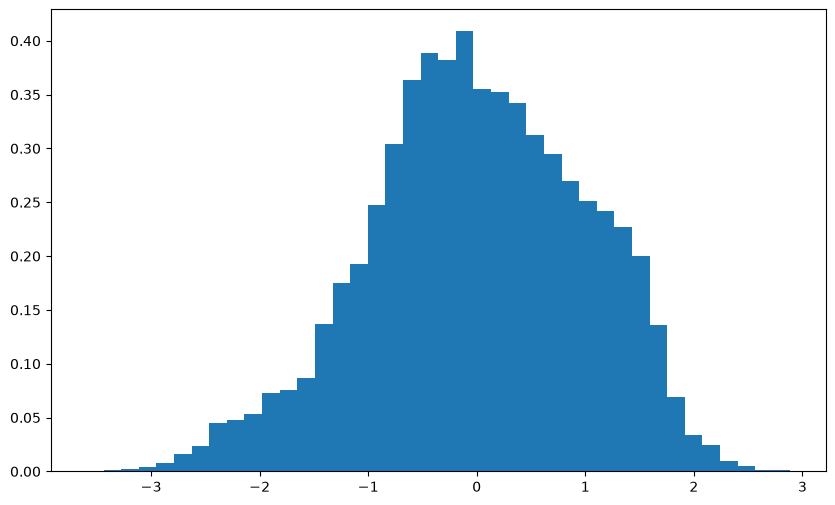

0   -0.141761
1   -0.141761
2   -0.141761
3   -0.141761
4   -0.141761
Name: rain, dtype: float64
rain


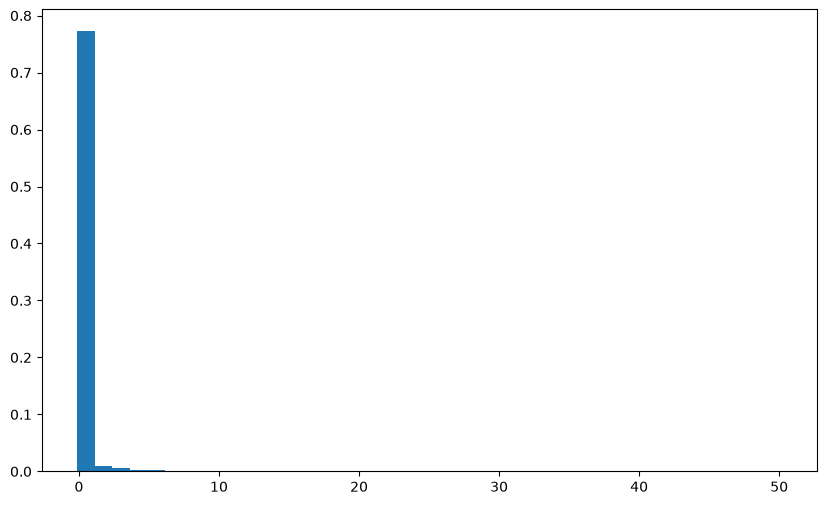

0   -0.199917
1   -0.199917
2   -0.199917
3   -0.199917
4   -0.199917
Name: showers, dtype: float64
showers


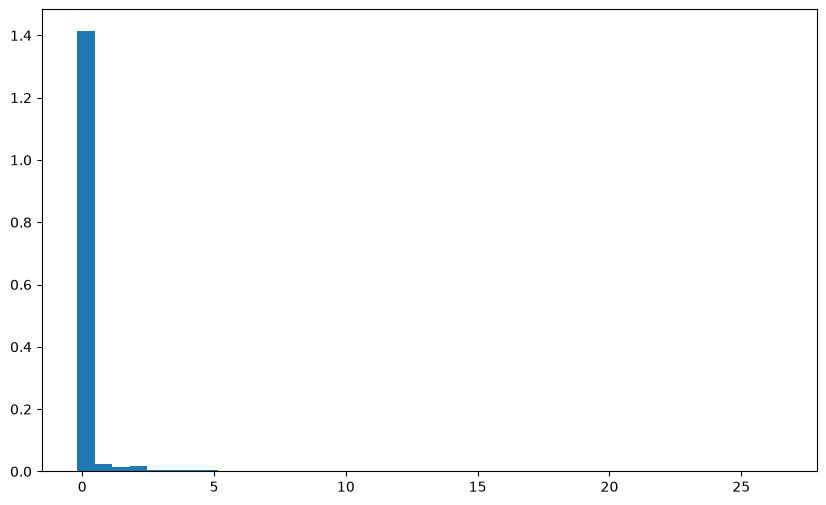

0   -0.121694
1   -0.121694
2   -0.121694
3   -0.121694
4   -0.121694
Name: snowfall, dtype: float64
snowfall


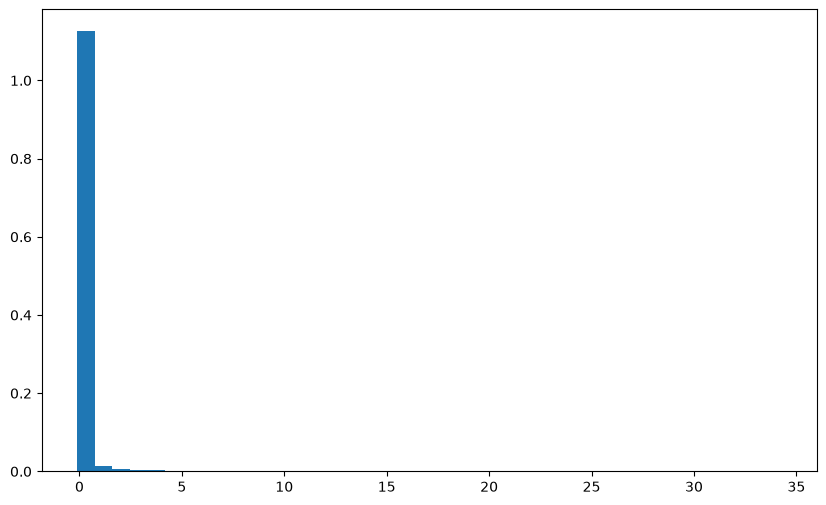

0   -0.19474
1   -0.19474
2   -0.19474
3   -0.19474
4   -0.19474
Name: snow_depth, dtype: float64
snow_depth


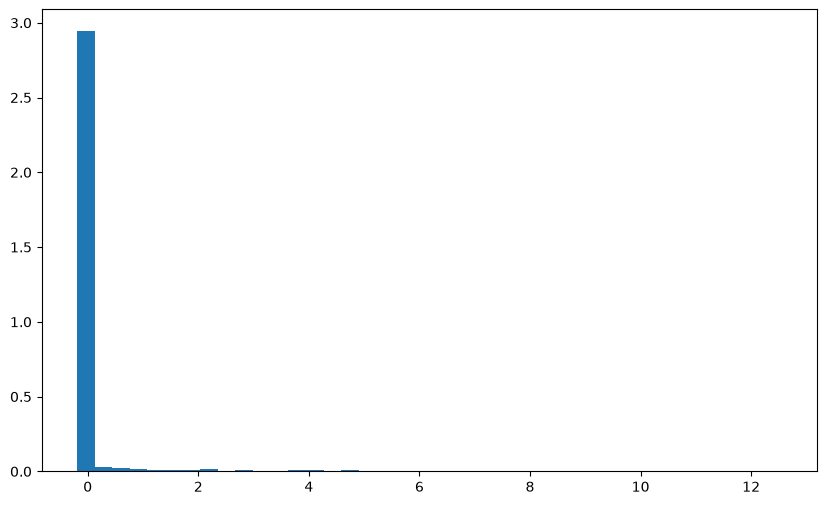

0   -0.359911
1   -0.359911
2   -0.359911
3   -0.359911
4   -0.359911
Name: weather_code, dtype: float64
weather_code


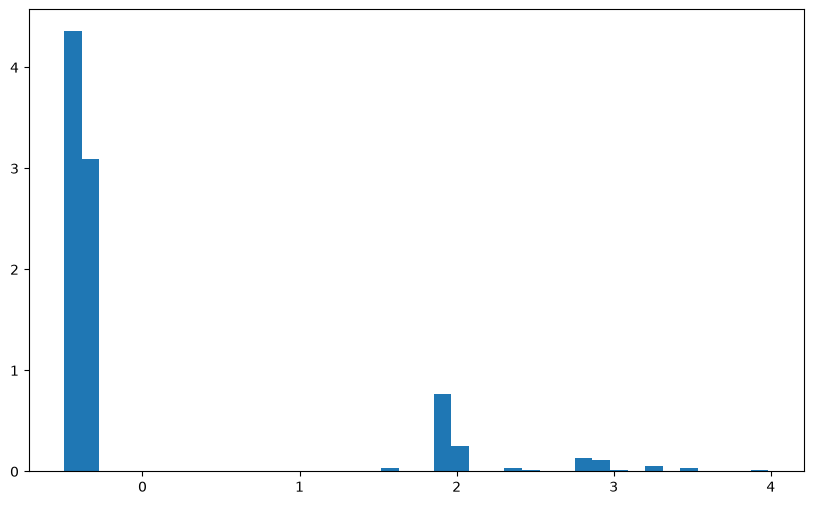

0    0.560563
1    0.702143
2    0.624918
3    0.534822
4    0.637789
Name: pressure_msl, dtype: float64
pressure_msl


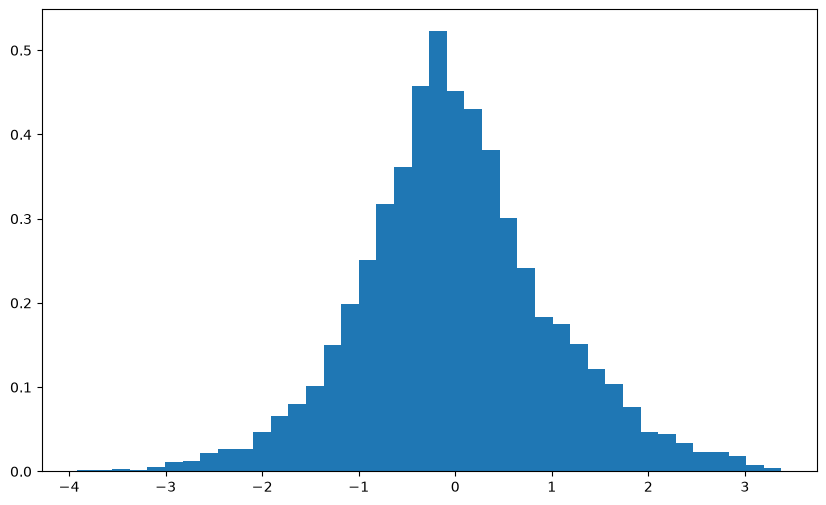

0    0.529870
1    0.678899
2    0.607350
3    0.511045
4    0.618268
Name: surface_pressure, dtype: float64
surface_pressure


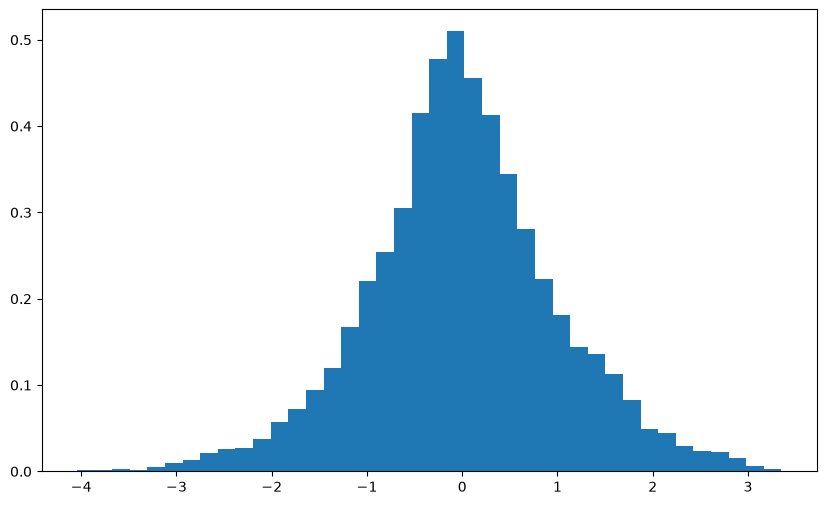

0    0.795075
1    0.952316
2    0.952316
3    0.952316
4    0.952316
Name: cloud_cover, dtype: float64
cloud_cover


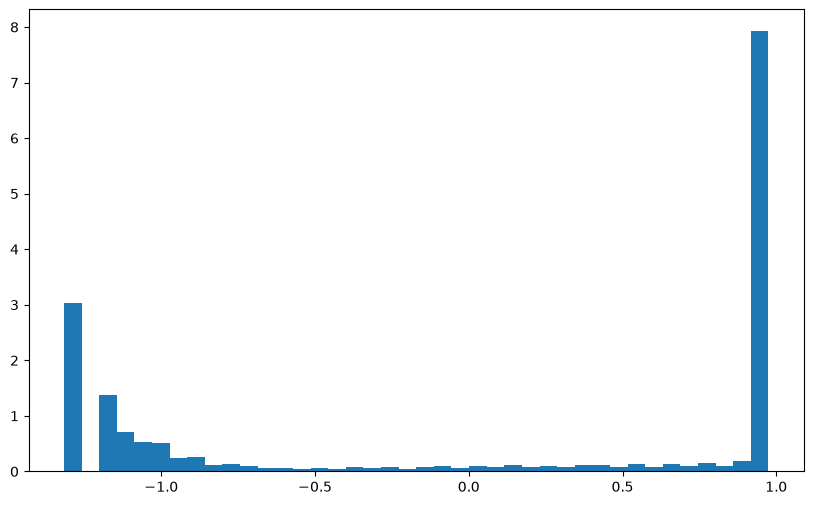

0    1.586676
1    1.755435
2    1.755435
3    1.755435
4    1.755435
Name: cloud_cover_mid, dtype: float64
cloud_cover_mid


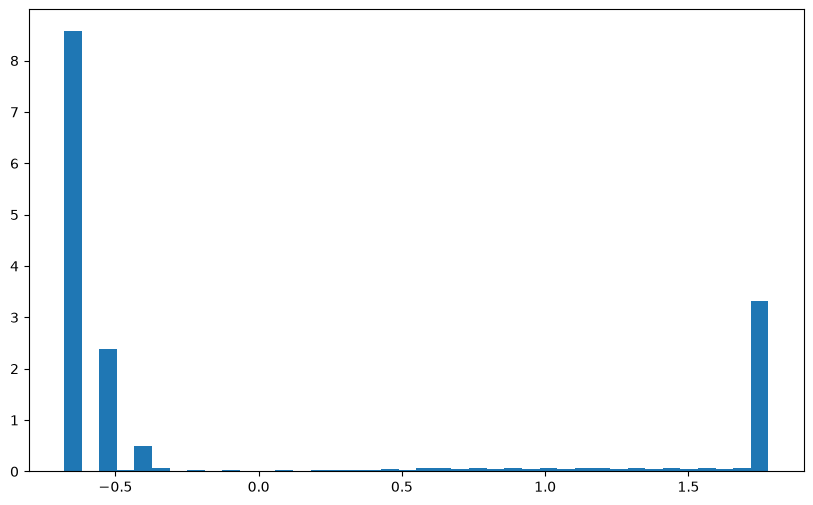

0   -0.741847
1   -0.741847
2   -0.741847
3   -0.741847
4   -0.741847
Name: cloud_cover_low, dtype: float64
cloud_cover_low


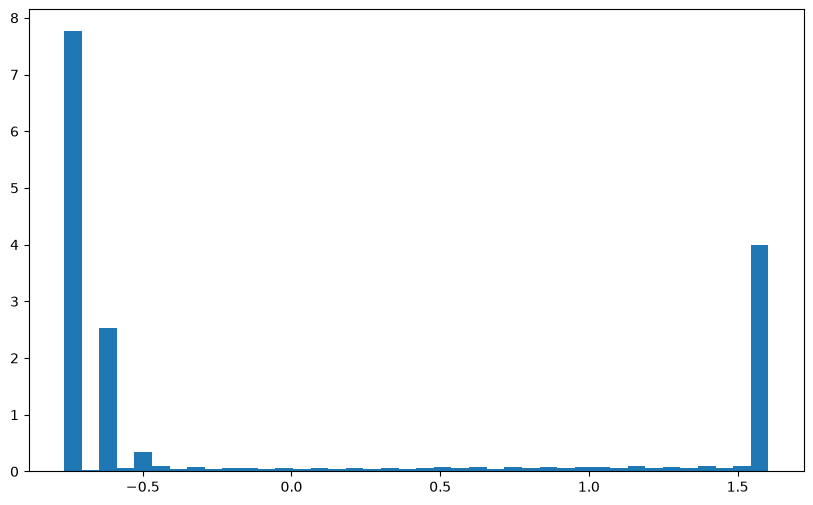

0   -0.730139
1   -0.730139
2   -0.842379
3    0.167778
4   -0.842379
Name: cloud_cover_high, dtype: float64
cloud_cover_high


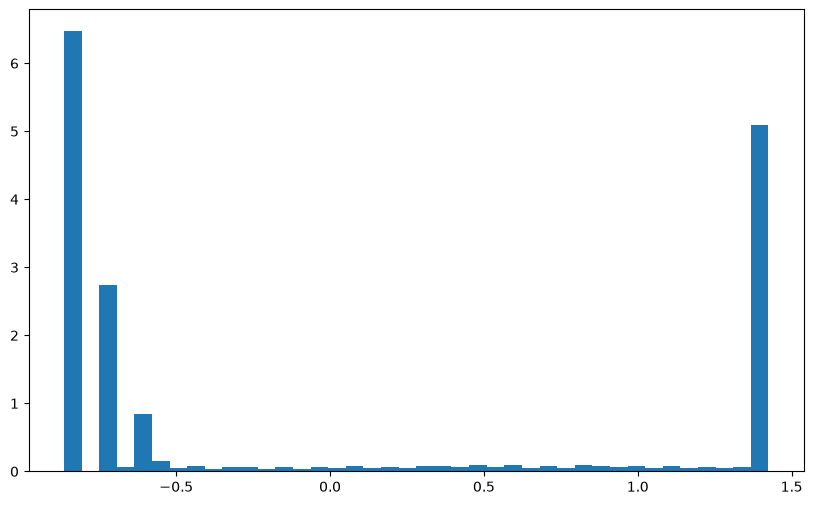

0    0.373702
1    0.373702
2    0.373702
3    0.373702
4    0.373702
Name: visibility, dtype: float64
visibility


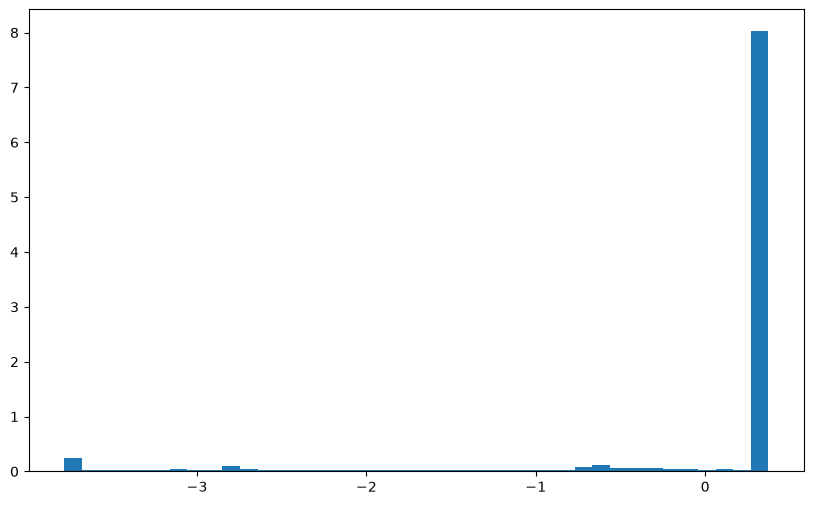

0    0.074732
1   -0.304893
2   -0.351007
3    0.017589
4   -0.395290
Name: wind_speed_10m, dtype: float64
wind_speed_10m


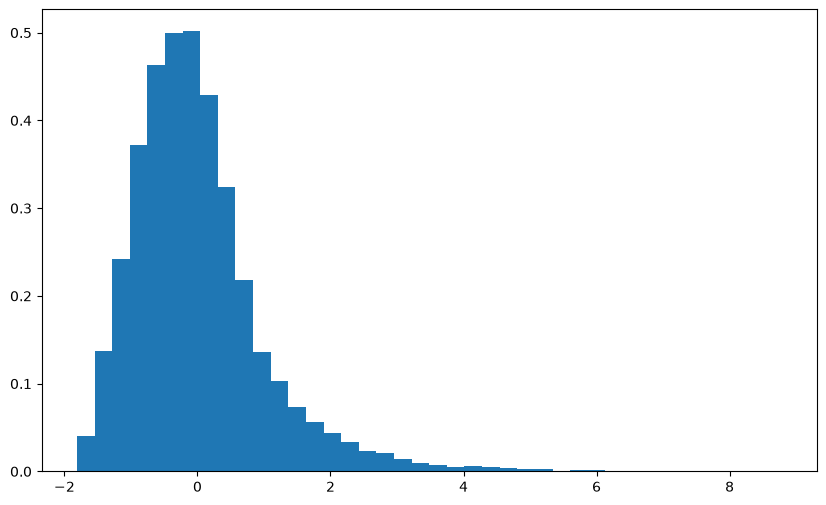

0   -0.500017
1   -0.585254
2   -0.621059
3   -0.442469
4   -0.637256
Name: wind_speed_80m, dtype: float64
wind_speed_80m


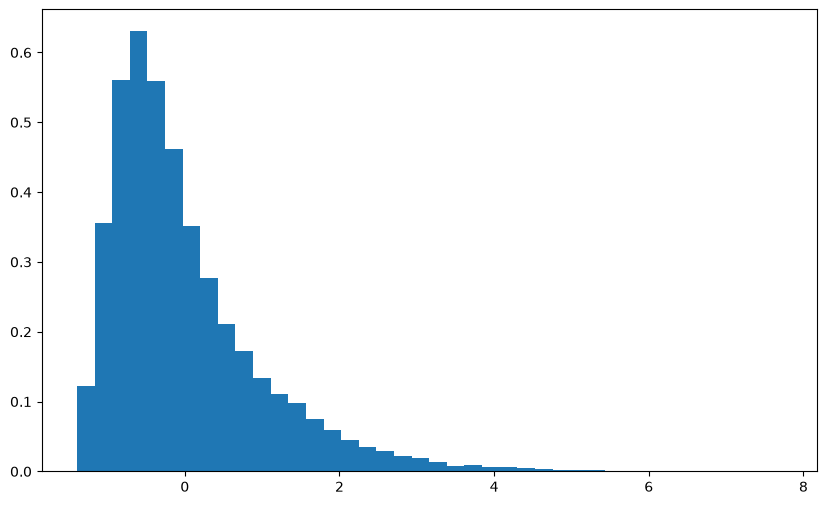

0    0.124702
1    0.275091
2    0.213104
3    0.137572
4    0.319526
Name: wind_direction_10m, dtype: float64
wind_direction_10m


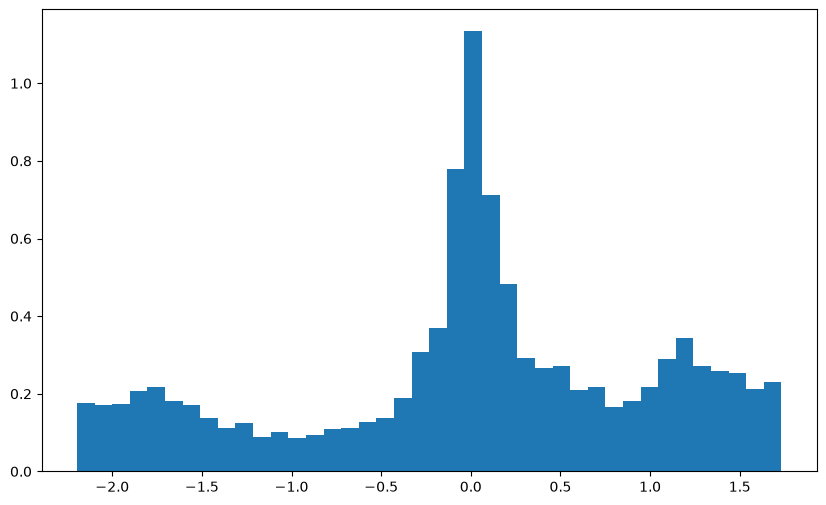

0    0.132626
1    0.557361
2    0.414427
3    0.173286
4    0.653013
Name: wind_direction_80m, dtype: float64
wind_direction_80m


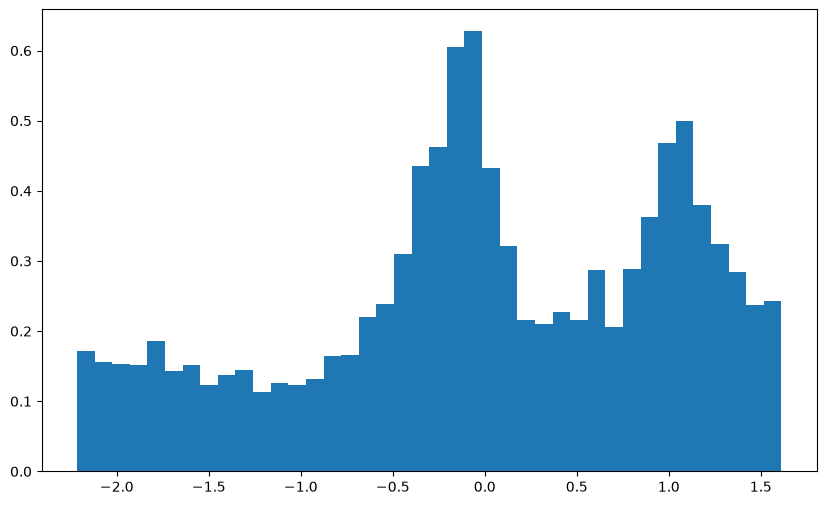

0   -0.494460
1   -0.562362
2   -0.630264
3   -0.494460
4   -0.630264
Name: wind_gusts_10m, dtype: float64
wind_gusts_10m


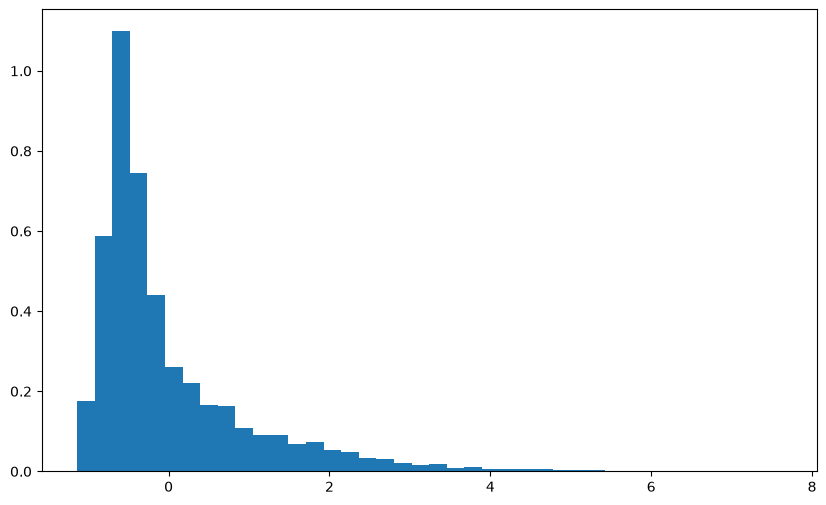

0   -0.303125
1   -0.314513
2   -0.274657
3   -0.234800
4   -0.274657
Name: temperature_80m, dtype: float64
temperature_80m


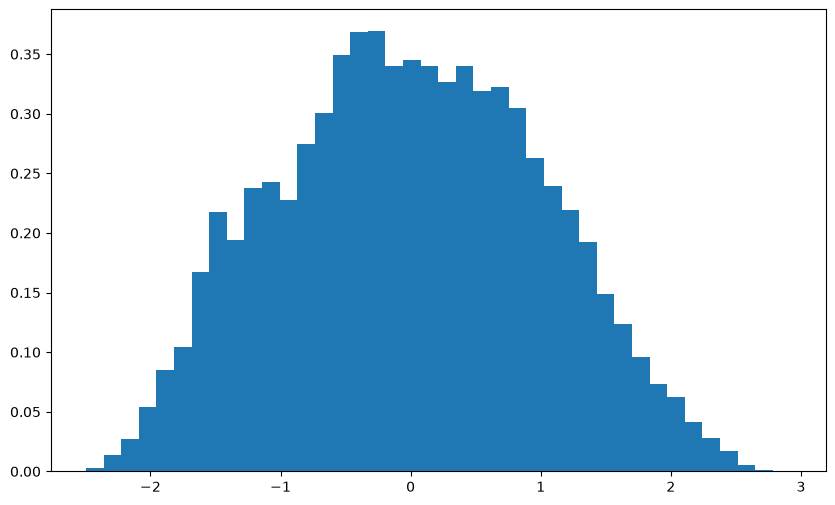

0   -0.718638
1   -0.708608
2   -0.618334
3   -0.688547
4   -0.638395
Name: surface_temperature, dtype: float64
surface_temperature


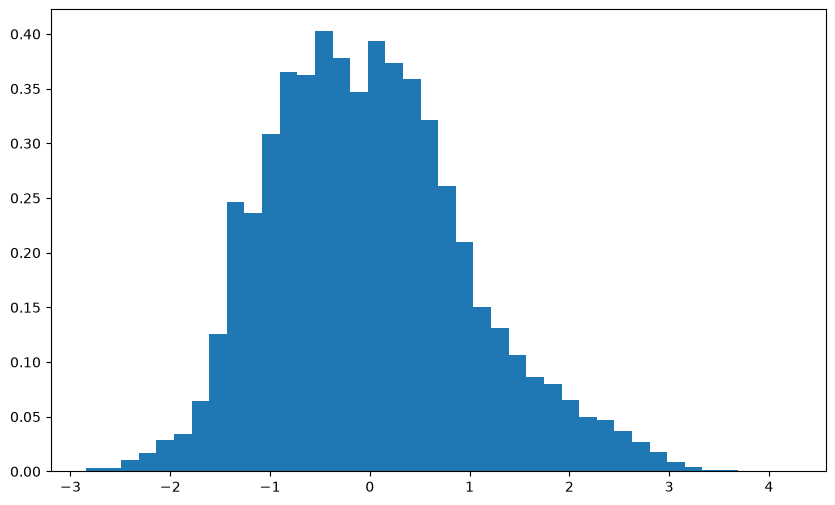

0   -0.810006
1   -0.830279
2   -0.830279
3   -0.843795
4   -0.843795
Name: soil_temperature_0_to_10cm, dtype: float64
soil_temperature_0_to_10cm


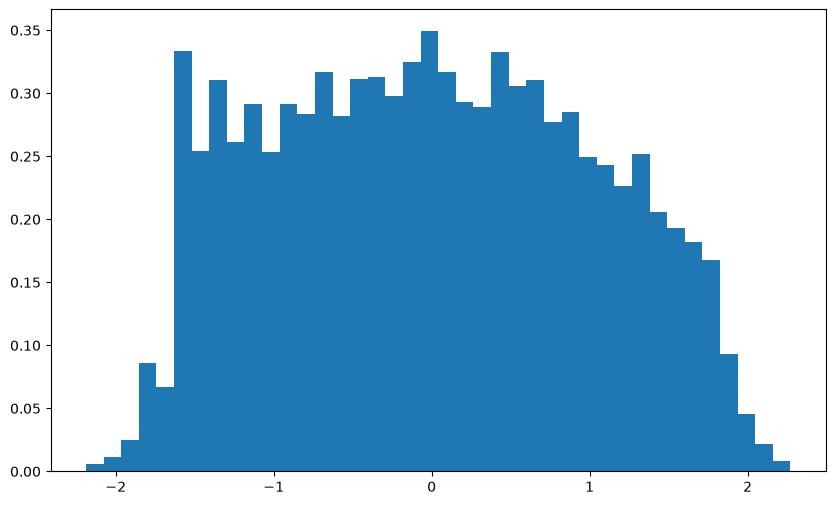

0   -1.149475
1   -1.149475
2   -1.149475
3   -1.138783
4   -1.138783
Name: soil_temperature_10_to_40cm, dtype: float64
soil_temperature_10_to_40cm


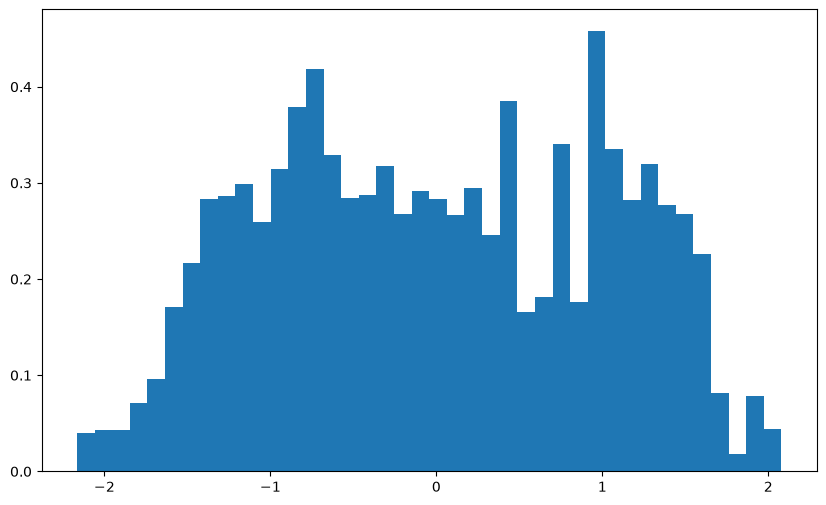

0    0.936817
1    0.936817
2    0.936817
3    0.936817
4    0.924131
Name: soil_moisture_0_to_10cm, dtype: float64
soil_moisture_0_to_10cm


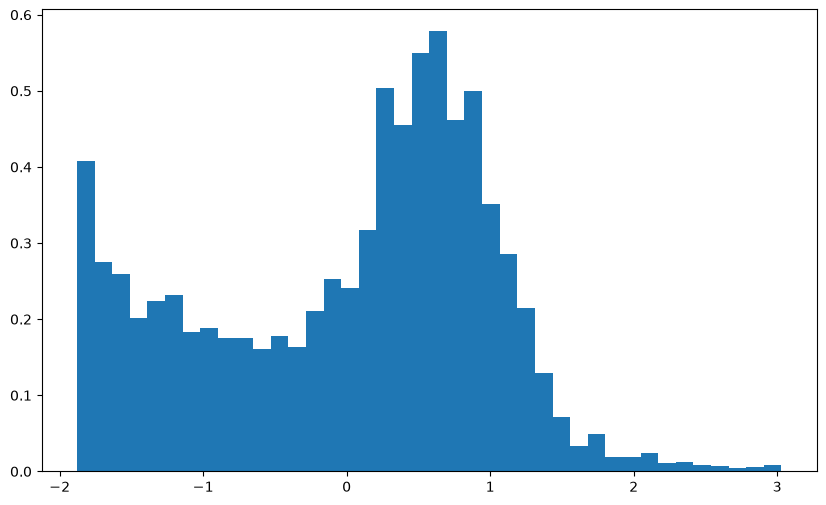

0    1.192361
1    1.192361
2    1.192361
3    1.179765
4    1.179765
Name: soil_moisture_10_to_40cm, dtype: float64
soil_moisture_10_to_40cm


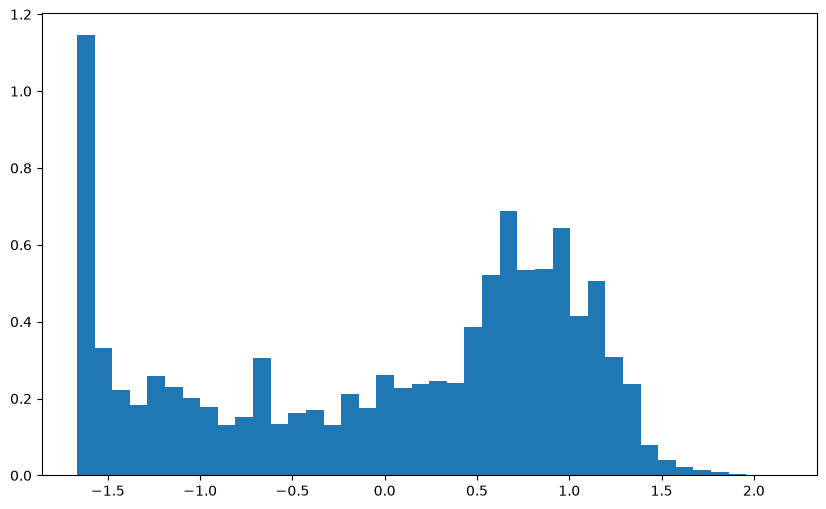

0    1.274215
1    1.274215
2    1.274215
3    1.274215
4    1.274215
Name: soil_moisture_40_to_100cm, dtype: float64
soil_moisture_40_to_100cm


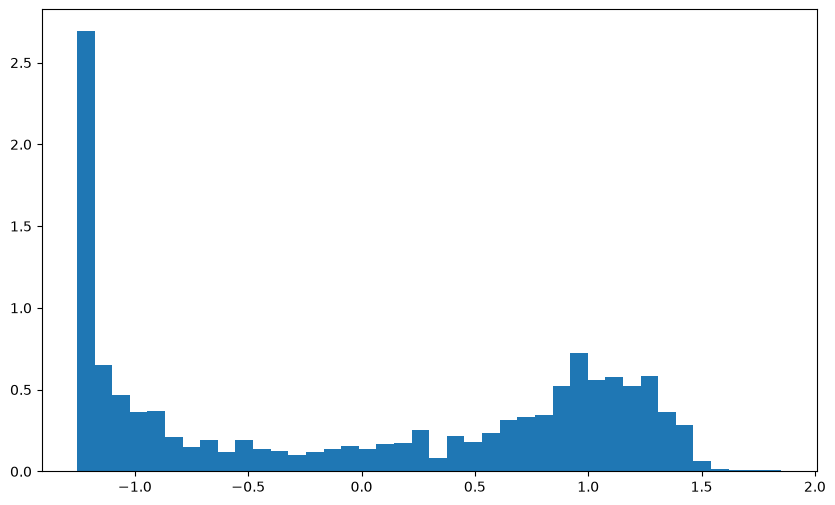

0   -0.2516
1   -0.2516
2   -0.2516
3   -0.2516
4   -0.2516
Name: soil_temperature_100_to_200cm, dtype: float64
soil_temperature_100_to_200cm


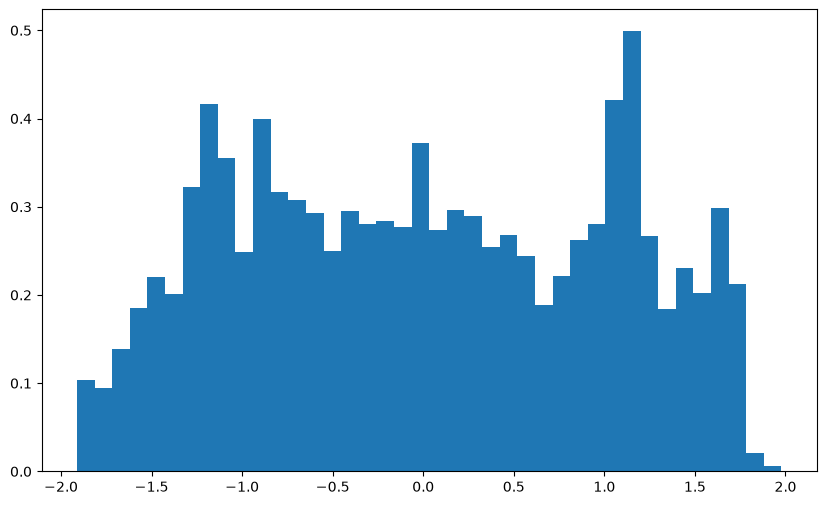

0   -1.133761
1   -1.133761
2   -1.133761
3   -1.133761
4   -1.133761
Name: soil_temperature_40_to_100cm, dtype: float64
soil_temperature_40_to_100cm


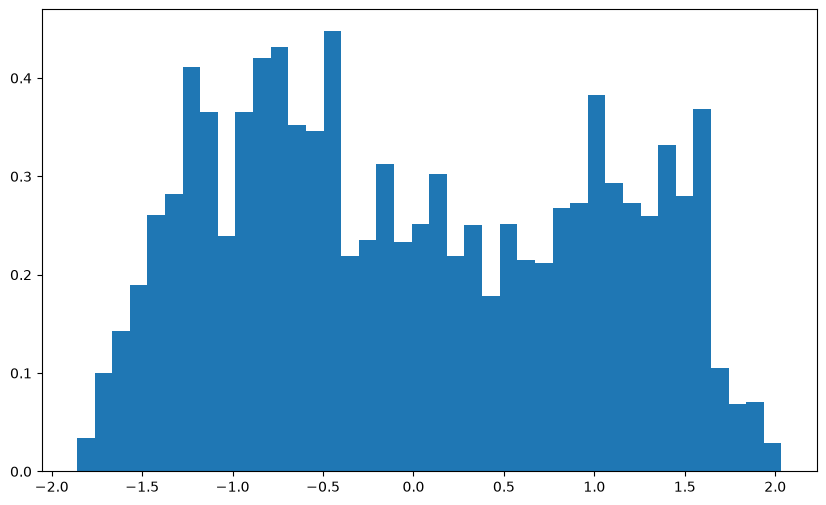

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: temperature_2m_previous_day1, dtype: float64
temperature_2m_previous_day1


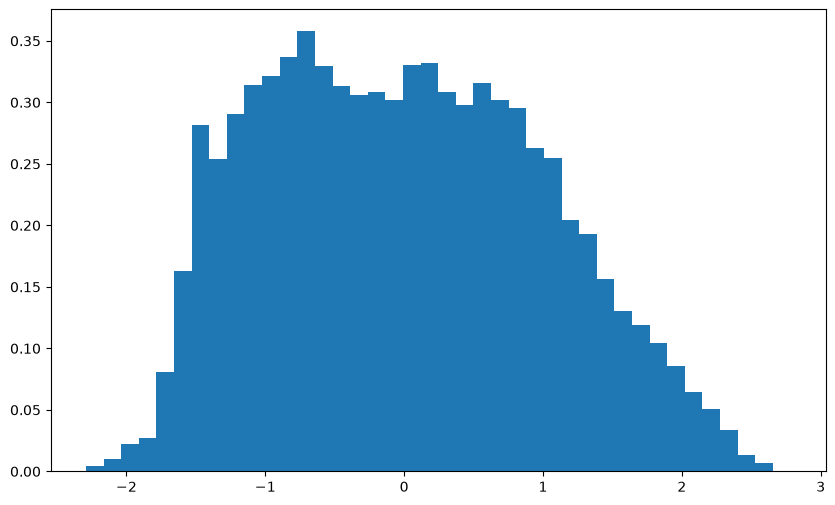

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: temperature_2m_previous_day3, dtype: float64
temperature_2m_previous_day3


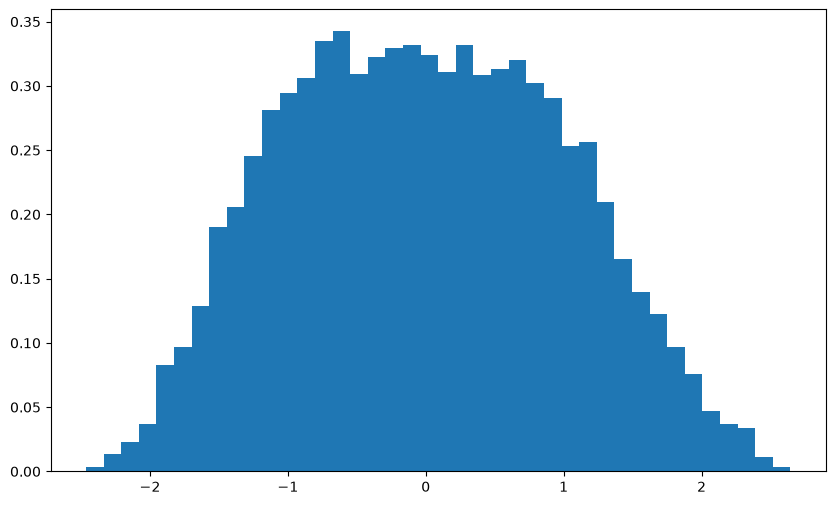

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: temperature_2m_previous_day5, dtype: float64
temperature_2m_previous_day5


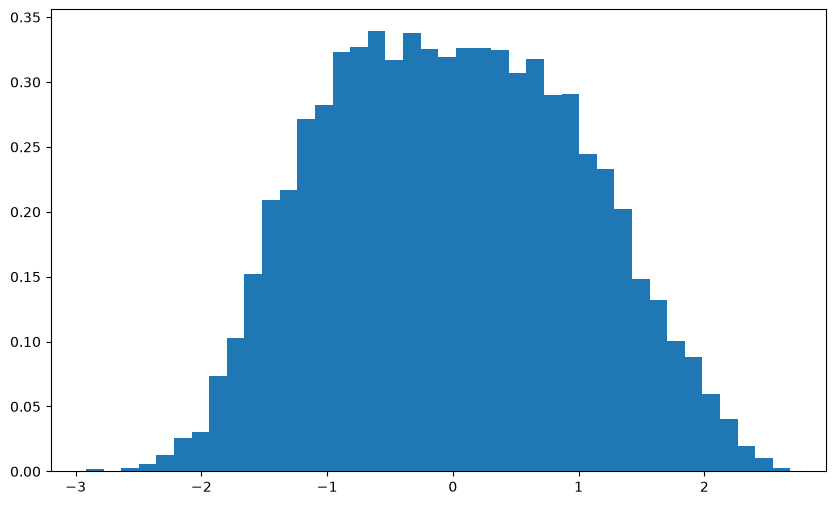

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: temperature_2m_previous_day7, dtype: float64
temperature_2m_previous_day7


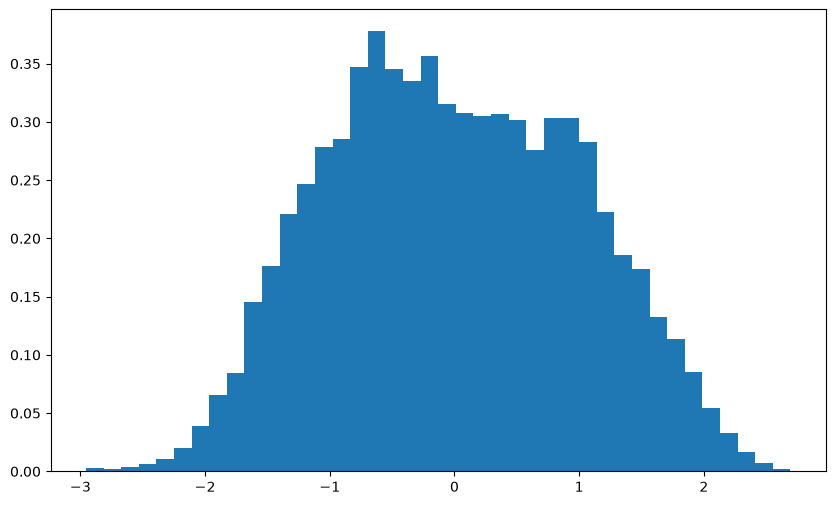

,temperature_2m,relative_humidity_2m,dew_point_2m,rain,showers,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,...,soil_temperature_10_to_40cm,soil_moisture_0_to_10cm,soil_moisture_10_to_40cm,soil_moisture_40_to_100cm,soil_temperature_100_to_200cm,soil_temperature_40_to_100cm,temperature_2m_previous_day1,temperature_2m_previous_day3,temperature_2m_previous_day5,temperature_2m_previous_day7
0,-0.511072,0.577909,-0.180832,-0.141761,-0.199917,-0.121694,-0.19474,-0.359911,0.560563,0.529870,...,-1.149475,0.936817,1.192361,1.274215,-0.251600,-1.133761,NaN,NaN,NaN,NaN
1,-0.488718,0.477599,-0.208404,-0.141761,-0.199917,-0.121694,-0.19474,-0.359911,0.702143,0.678899,...,-1.149475,0.936817,1.192361,1.274215,-0.251600,-1.133761,NaN,NaN,NaN,NaN
2,-0.410481,0.327134,-0.192436,-0.141761,-0.199917,-0.121694,-0.19474,-0.359911,0.624918,0.607350,...,-1.149475,0.936817,1.192361,1.274215,-0.251600,-1.133761,NaN,NaN,NaN,NaN
3,-0.438423,0.276979,-0.260692,-0.141761,-0.199917,-0.121694,-0.19474,-0.359911,0.534822,0.511045,...,-1.138783,0.936817,1.179765,1.274215,-0.251600,-1.133761,NaN,NaN,NaN,NaN
4,-0.432835,0.226824,-0.284184,-0.141761,-0.199917,-0.121694,-0.19474,-0.359911,0.637789,0.618268,...,-1.138783,0.924131,1.179765,1.274215,-0.251600,-1.133761,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40483,0.846894,-1.327984,0.098550,-0.141761,-0.199917,-0.121694,-0.19474,-0.500085,0.084342,0.176788,...,1.438009,-1.879485,-1.667078,-1.244091,0.578551,1.162644,1.033380,1.057671,1.111601,1.140896
40484,0.768658,-1.177518,0.162108,-0.141761,-0.199917,-0.121694,-0.19474,-0.500085,0.148696,0.235692,...,1.438009,-1.879485,-1.667078,-1.244091,0.578551,1.162644,0.818031,0.997048,1.040338,1.020097
40485,0.690421,-1.077208,0.165109,-0.141761,-0.199917,-0.121694,-0.19474,-0.500085,0.174438,0.254604,...,1.438009,-1.879485,-1.667078,-1.244091,0.578551,1.162644,0.655206,0.958469,0.980038,0.899298
40486,0.645714,-0.976898,0.206071,-0.141761,-0.199917,-0.121694,-0.19474,-0.500085,0.187308,0.263445,...,1.438009,-1.879485,-1.667078,-1.244091,0.578551,1.162644,0.576419,0.848244,0.919738,0.783990


In [212]:
def standardizacijasvega(df):
    brojevi = df.select_dtypes(include="number")
    n=len(brojevi.columns)
    print(n)


    
    for i in range(n):
        kolona = brojevi.columns[i]
        mu = brojevi[kolona].mean()
        sigma = brojevi[kolona].std()

        brojevi[kolona]=(brojevi[kolona]-mu)/sigma
        print(brojevi[kolona].head())
        print(brojevi.columns[i])



        plt.figure(figsize=(10, 6))
        plt.hist(brojevi[kolona], bins=40, density=True)
        plt.show()
    return brojevi
        
        
standardizacijasvega(df)

        

In [213]:
def histplotsve():
    for column in brojevi.column:
        sttemp1=standardizacijasvega(brojevi)
        plt.figure(figsize=(10, 6))
        plt.hist(sttemp1, bins=70, density=True)
        plt.show()

"""
sttemp1=standardizacija1(temp1)
plt.figure(figsize=(10, 6))
plt.hist(sttemp1, bins=70, density=True)
plt.show()
sttemp3=standardizacija1(temp3)
plt.figure(figsize=(10, 6))
plt.hist(sttemp3, bins=70, density=True)
plt.show()
sttemp5=standardizacija1(temp5)
plt.figure(figsize=(10, 6))
plt.hist(sttemp5, bins=70, density=True)
plt.show()
sttemp7=standardizacija1(temp7)
plt.figure(figsize=(10, 6))
plt.hist(sttemp7, bins=7brojevi = df.select_dtypes(include="number")0, density=True)
plt.show()


stsf1=standardizacija1(sf1)
plt.figure(figsize=(10, 6))
plt.hist(stsf1, bins=70, density=True)
plt.show()
stsf3=standardizacija1(sf3)
plt.figure(figsize=(10, 6))
plt.hist(stsf3, bins=70, density=True)
plt.show()
stsf5=standardizacija1(sf5)
plt.figure(figsize=(10, 6))
plt.hist(stsf5, bins=70, density=True)
plt.show()
stsf7=standardizacija1(sf7)
plt.figure(figsize=(10, 6))
plt.hist(stsf7, bins=70, density=True)
plt.show()
lista=[temp1,temp3,temp5,temp7]
"""



'\nsttemp1=standardizacija1(temp1)\nplt.figure(figsize=(10, 6))\nplt.hist(sttemp1, bins=70, density=True)\nplt.show()\nsttemp3=standardizacija1(temp3)\nplt.figure(figsize=(10, 6))\nplt.hist(sttemp3, bins=70, density=True)\nplt.show()\nsttemp5=standardizacija1(temp5)\nplt.figure(figsize=(10, 6))\nplt.hist(sttemp5, bins=70, density=True)\nplt.show()\nsttemp7=standardizacija1(temp7)\nplt.figure(figsize=(10, 6))\nplt.hist(sttemp7, bins=7brojevi = df.select_dtypes(include="number")0, density=True)\nplt.show()\n\n\nstsf1=standardizacija1(sf1)\nplt.figure(figsize=(10, 6))\nplt.hist(stsf1, bins=70, density=True)\nplt.show()\nstsf3=standardizacija1(sf3)\nplt.figure(figsize=(10, 6))\nplt.hist(stsf3, bins=70, density=True)\nplt.show()\nstsf5=standardizacija1(sf5)\nplt.figure(figsize=(10, 6))\nplt.hist(stsf5, bins=70, density=True)\nplt.show()\nstsf7=standardizacija1(sf7)\nplt.figure(figsize=(10, 6))\nplt.hist(stsf7, bins=70, density=True)\nplt.show()\nlista=[temp1,temp3,temp5,temp7]\n'

Ukupno: 22272
Train: 17817
Validation: 2227
Test: 2228


/tmp/ipykernel_314722/3538631359.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


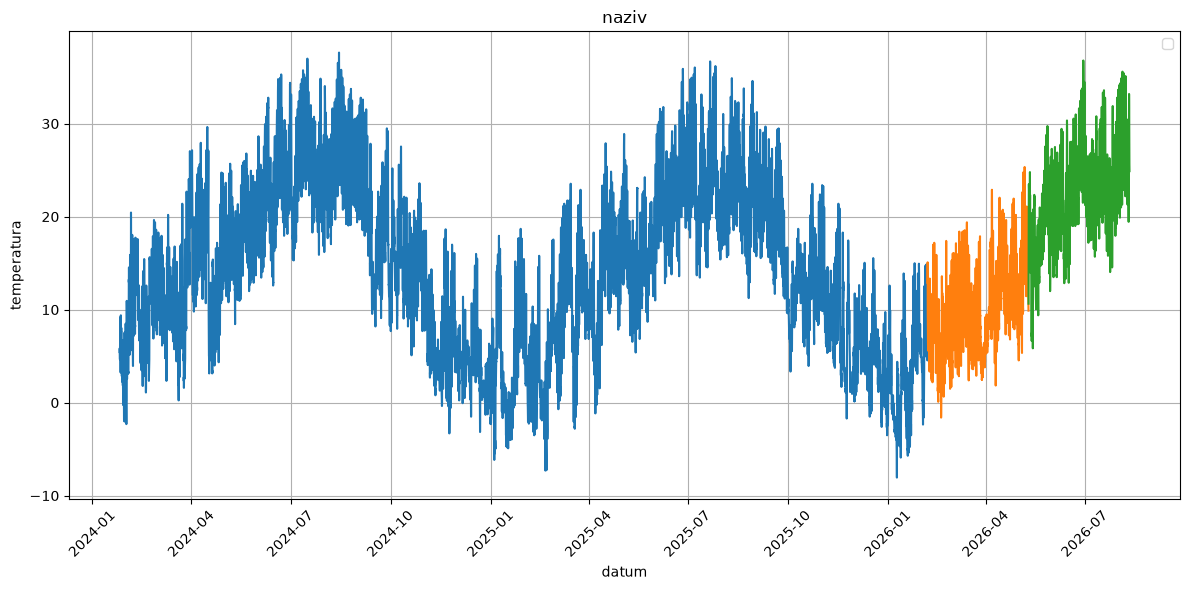

In [ ]:
from sklearn.model_selection import train_test_split
date=df["date"]
n=len(df)

trsize=int(n*0.8)
valsize=int(len(df)*0.1)

trening=df.iloc[:trsize]
validation=df.iloc[trsize:trsize+valsize]
test=df.iloc[trsize+valsize:]


print("Ukupno:", len(date))

print("Train:", len(trening))
print("Validation:", len(validation))
print("Test:", len(test))

test.head()

def plot2(x, y, x1, y1, naziv,x11,y22,x3,y3):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)
    plt.plot(x11, y22)
    plt.plot(x3, y3)


    plt.xlabel(x1)
    plt.ylabel(y1)
    plt.title(naziv)
    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

plot2(trening["date"],trening["temperature_2m"],"datum","temperatura","naziv",validation["date"],validation["temperature_2m"],test["date"],test["temperature_2m"])
#plot(validation["date"],validation["temperature_2m"])
#plot(test["date"],test["temperature_2m"])

/tmp/ipykernel_314722/3407071470.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


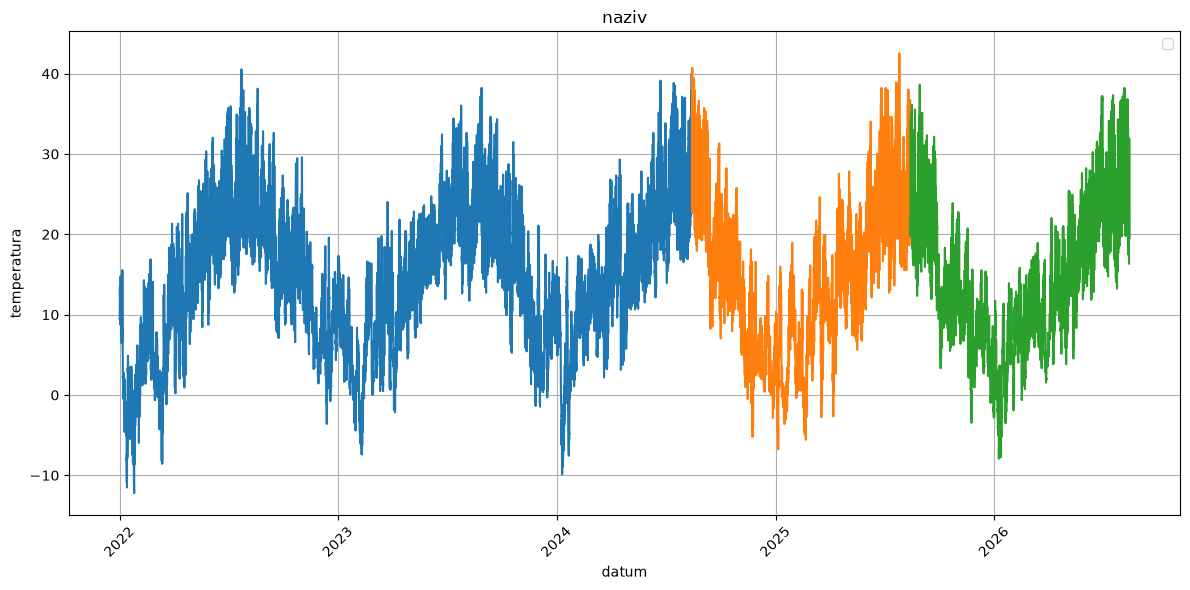

In [208]:
date=df["date"]
n=len(df)

trening=df[df["date"]<"2024-08-14"]
validacija=df[(df["date"]>= "2024-08-14")&(df["date"] <"2025-08-14")]
test=df[df["date"]>= "2025-08-14"]


def plot2(x, y, x1, y1, naziv,x11,y22,x3,y3):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)
    plt.plot(x11, y22)
    plt.plot(x3, y3)


    plt.xlabel(x1)
    plt.ylabel(y1)
    plt.title(naziv)
    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

plot2(trening["date"],trening["temperature_2m"],"datum","temperatura","naziv",validacija["date"],validacija["temperature_2m"],test["date"],test["temperature_2m"])
